In [1]:
import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import datetime as dt
import scipy.io as sio
import shapefile
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import pearsonr
from matplotlib import cm
import h5py

In [2]:
def nan_helper(y):
    """Helper to handle indices and logical indices of NaNs.

    Input:
        - y, 1d numpy array with possible NaNs
    Output:
        - nans, logical indices of NaNs
        - index, a function, with signature indices= index(logical_indices),
          to convert logical indices of NaNs to 'equivalent' indices
    Example:
        >>> # linear interpolation of NaNs
        >>> nans, x= nan_helper(y)
        >>> y[nans]= np.interp(x(nans), x(~nans), y[~nans])
    """

    return np.isnan(y), lambda z: z.nonzero()[0]

In [3]:
#RUN
def ts_smet4irr(sm, et, a, b, z, RF, thr=None):
    
    
    p_sim = z * (sm[1:] - sm[:-1]) + ((a * sm[1:]**b + a * sm[:-1]**b) / 2.) + ((RF * sm[1:] * et[1:] + RF * sm[:-1] * et[:-1]) / 2.)

    p_sim[abs(np.diff(sm))<=0.001]=0.0
    p_sim[p_sim < 1.0]=0.0   # 2mm/day for NN=4 -> 0.5
   
    return np.clip(p_sim, 0, thr)

    
def swicomp_nan(in_data, in_jd, ctime):


    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    D = in_jd[ID]
    SWI = in_data[ID]
    tdiff = np.diff(D)


    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI

    return filtered

In [4]:
AGG = 7       
T = 2

In [5]:
#a,b,Z,F

A = np.loadtxt('C:/Projects/IrrigationEU/Puglia_exp/ELAB/a_FOGGIA_distributed_20182024.txt')
B = np.loadtxt('C:/Projects/IrrigationEU/Puglia_exp/ELAB/b_FOGGIA_distributed_20182024.txt')
z = np.loadtxt('C:/Projects/IrrigationEU/Puglia_exp/ELAB/Z_FOGGIA_distributed_20182024.txt')
f = np.loadtxt('C:/Projects/IrrigationEU/Puglia_exp/ELAB/F_FOGGIA_distributed_20182024.txt')



a = A.reshape(A.shape[0]* A.shape[1])
b = B.reshape(B.shape[0]* B.shape[1])
Z = z.reshape(z.shape[0]* z.shape[1])
F = f.reshape(f.shape[0]* f.shape[1])

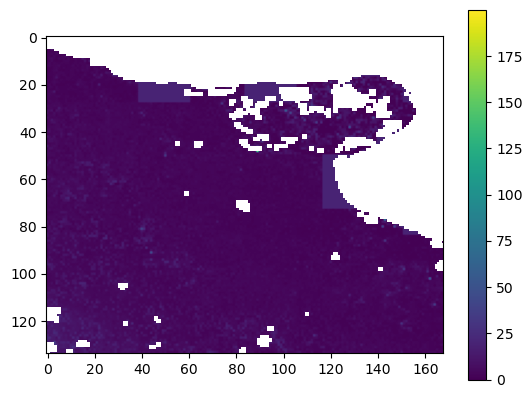

In [6]:
plt.imshow(A)
plt.colorbar()

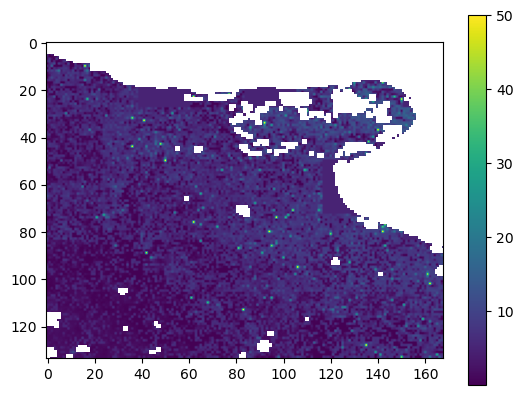

In [7]:
plt.imshow(B)
plt.colorbar()

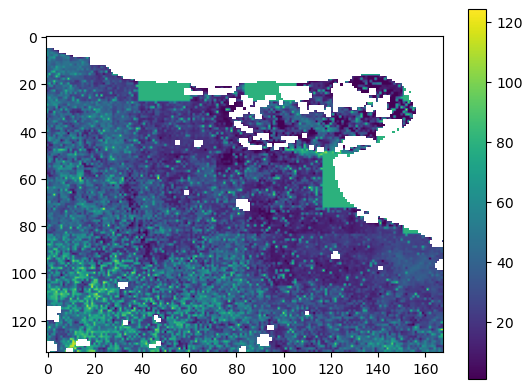

In [8]:
plt.imshow(z)
plt.colorbar()

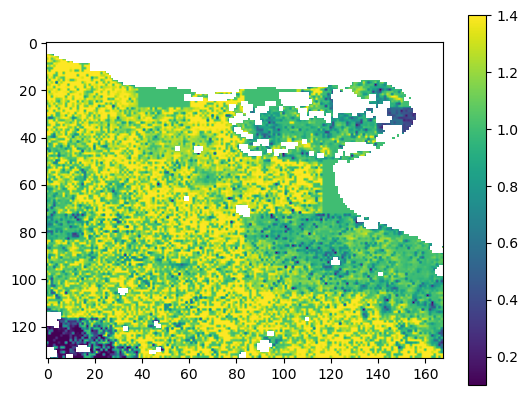

In [9]:
plt.imshow(f)
plt.colorbar()

In [12]:
datasm = h5py.File('C:/Projects/IrrigationEU/Puglia_exp/ELAB/S1_18_24_REGRIDDED.hdf5','r')
sm = np.array(datasm['sm'][:,:,:])
lon = datasm['lon'][:,:]
lat = datasm['lat'][:,:]
datasm.close()

datapet = h5py.File('C:/Projects/IrrigationEU/Puglia_exp/ELAB/ERA5_Land_pet_18_24_REGRIDDED.hdf5','r')
petdaily = np.array(datapet['pet'][:,:,:])

datapet.close()

datatp = h5py.File('C:/Projects/IrrigationEU/Puglia_exp/ELAB/ERA5_Land_rain_18_24_REGRIDDED.hdf5','r')
tp = np.array(datatp['tp'][:,:,:])
datatp.close()



In [13]:
lon.shape

(134, 168)

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_3696\2800171602.py:1: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(tp,axis=0))


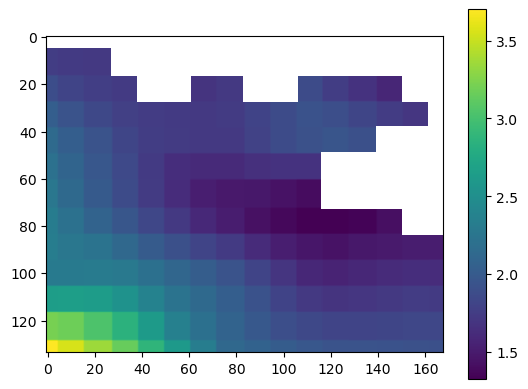

In [14]:
plt.imshow(np.nanmean(tp,axis=0))
plt.colorbar()

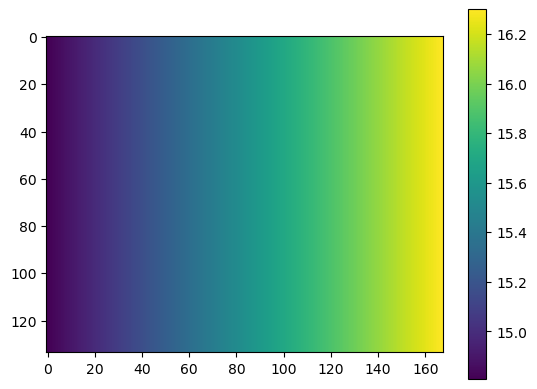

In [15]:
plt.imshow(lon)
plt.colorbar()

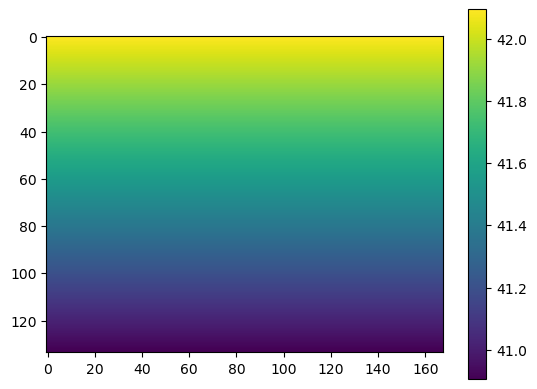

In [16]:
plt.imshow(lat)
plt.colorbar()

In [17]:
print (sm.shape)
print (petdaily.shape)
print (tp.shape)

(2557, 134, 168)
(2557, 134, 168)
(2557, 134, 168)


In [18]:
for i in range(petdaily.shape[1]):
    for j in range(petdaily.shape[2]):
        y = petdaily[:,i,j]
        B = np.nanmean(y,axis = 0)
        if np.isfinite(B) == True:
            nans, x= nan_helper(y)
            y[nans] = np.interp(x(nans), x(~nans), y[~nans])

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_3696\260604304.py:4: RuntimeWarning: Mean of empty slice
  B = np.nanmean(y,axis = 0)


In [19]:
datex= [dt.datetime(2018,1,1)+dt.timedelta(days=i) for i in range(sm.shape[0])]

In [20]:
datex[0]

datetime.datetime(2018, 1, 1, 0, 0)

In [21]:
datex[-1]

datetime.datetime(2024, 12, 31, 0, 0)

In [22]:
JDAYSS = pd.Series(datex,datex)

JDAYS = JDAYSS.index.to_julian_date().to_numpy()

In [23]:

for i in range(sm.shape[1]):
    for j in range(sm.shape[2]):
        y = sm[:,i,j]
        A = np.nanmean(y,axis = 0)
        if np.isfinite(A) == True:
            nans, x= nan_helper(y)
            y[nans] = np.interp(x(nans), x(~nans), y[~nans])

C:\Users\Jacopo\AppData\Local\Temp\ipykernel_3696\1117832374.py:4: RuntimeWarning: Mean of empty slice
  A = np.nanmean(y,axis = 0)


C:\Users\Jacopo\AppData\Local\Temp\ipykernel_3696\1023155271.py:6: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(SWI,axis = 0))


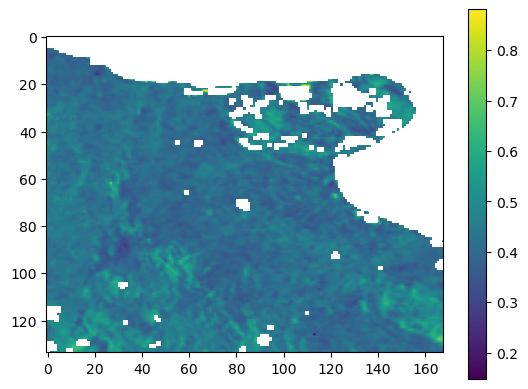

In [24]:
SWI = np.empty((sm.shape))
for i in range(sm.shape[1]):
    for j in range(sm.shape[2]):
        SWI[:,i,j] = swicomp_nan(sm[:,i,j], JDAYS,T)
                              
plt.imshow(np.nanmean(SWI,axis = 0))
plt.colorbar()
plt.show()

In [25]:

SWI_masked_flat = np.empty((SWI.shape[0], SWI.shape[1]*SWI.shape[2]))
for i in range(SWI.shape[0]):
    SWI_masked_flat[i,:] = SWI[i,:,:].reshape(SWI.shape[1]*SWI.shape[2])

In [26]:
rainfall_masked_flat = np.empty((tp.shape[0], tp.shape[1]*tp.shape[2]))
for i in range(tp.shape[0]):
    rainfall_masked_flat[i,:] = tp[i,:,:].reshape(tp.shape[1]*tp.shape[2])

In [27]:
petdaily_masked_flat = np.empty((petdaily.shape[0], petdaily.shape[1]*petdaily.shape[2]))
for i in range(petdaily.shape[0]):
    petdaily_masked_flat[i,:] = petdaily[i,:,:].reshape(petdaily.shape[1]*petdaily.shape[2])

# SIMULATION (Ranifall + Irrigation)

In [28]:
psim = np.empty((sm.shape[0]-1,sm.shape[1]*sm.shape[2]))
for i in range(psim.shape[1]):
    psim[:,i] = ts_smet4irr(SWI_masked_flat[:,i],petdaily_masked_flat[:,i],a[i], b[i], Z[i], F[i])

In [29]:
#dataframes
PSIM_dataframe = pd.DataFrame(psim, index = datex[:-1])
RAIN_dataframe = pd.DataFrame(rainfall_masked_flat[:-1,:], index = datex[:-1])

In [30]:
PSIM_dataframe

,0,1,2,3,4,5,6,7,8,9,...,22502,22503,22504,22505,22506,22507,22508,22509,22510,22511
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,5.281558,8.566893,6.547654,5.751002,3.658142,3.665689,6.639114,4.834128
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.258895,0.000000,2.204496,2.707019,2.489792,2.173026,1.768290,2.192251,2.513309,2.455995
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.804966,0.000000,1.544157,1.306164,1.558738,0.000000,1.391161,1.961217,1.572468,1.994016
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.186612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.130869,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.177287,2.601368,3.556045,3.734193,3.077596,3.459370,3.898929,4.167936,3.368234,3.939851
2024-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.961613,2.336306,2.966790,3.127745,2.553129,2.935430,3.198195,3.484333,2.585284,3.336840
2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.793605,2.125372,2.566474,2.711301,2.209328,2.606399,2.775746,3.046537,2.096987,2.953520
2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.682303,1.986565,2.311166,2.446223,1.992757,2.402573,2.519289,2.769029,1.795832,2.712935


In [31]:
RAIN_dataframe

,0,1,2,3,4,5,6,7,8,9,...,22502,22503,22504,22505,22506,22507,22508,22509,22510,22511
2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001714,0.001714,0.001714,0.001714,0.001252,0.001252,0.001252,0.001252,0.001252,0.001252
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.679129,0.679129,0.679129,0.679129,0.637764,0.637764,0.637764,0.637764,0.637764,0.637764
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.110669,5.110669,5.110669,5.110669,5.141395,5.141395,5.141395,5.141395,5.141395,5.141395
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.964444,1.964444,1.964444,1.964444,2.081180,2.081180,2.081180,2.081180,2.081180,2.081180
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.057557,0.057557,0.057557,0.057557,0.030318,0.030318,0.030318,0.030318,0.030318,0.030318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.124906,2.124906,2.124906,2.124906,1.839936,1.839936,1.839936,1.839936,1.839936,1.839936
2024-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.145652,0.145652,0.145652,0.145652,0.099756,0.099756,0.099756,0.099756,0.099756,0.099756
2024-12-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.011939,0.011939,0.011939,0.011939,0.002134,0.002134,0.002134,0.002134,0.002134,0.002134
2024-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
PSIM_dataframe_W = PSIM_dataframe.resample(str(AGG)+'D',convention='end').sum()

In [33]:
RAIN_dataframe_W = RAIN_dataframe.resample(str(AGG)+'D',convention='end').sum()

In [34]:
IRR_W = PSIM_dataframe_W - RAIN_dataframe_W
IRR_clipped = IRR_W.clip(0,1000)
IRR_clipped[IRR_clipped/RAIN_dataframe_W < 0.2] = 0
#IRR_clipped[(IRR_clipped.index.month < 5) | (IRR_clipped.index.month > 9) ] = 0

The following step can be avoided as we will have bi-weekly datasets

In [35]:
#for daily unmasked data

IRR_clipped_dailyvalue = IRR_clipped.reindex(pd.date_range('2018-01-01', '2024-12-31'), fill_value = np.nan) 
IRR_clipped_dailyvaluee = IRR_clipped_dailyvalue.interpolate(method='linear')
IRR_clippedd = IRR_clipped_dailyvaluee/AGG

<AxesSubplot:>

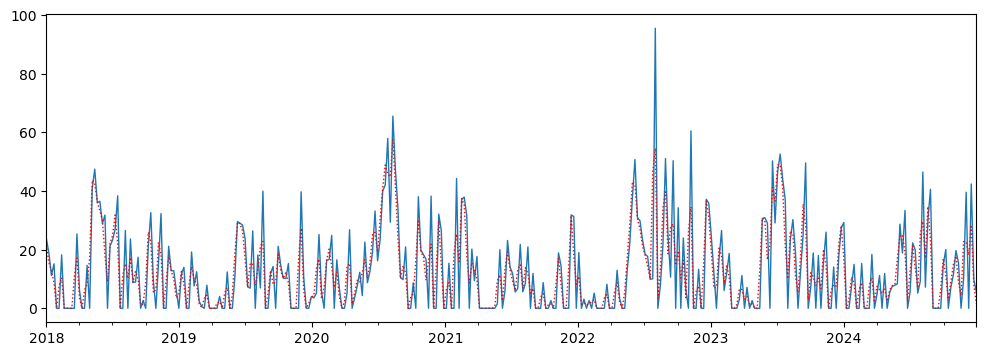

In [42]:
fig = plt.figure(figsize=(12,4))
IRR_clipped[20000].plot(linewidth=1) #original
IRR_clippedd[20000].resample(str(AGG)+'D',convention='end').sum().plot(linewidth=1, linestyle ='dotted',color='r') #weekly disaggregated


In [43]:
IRR_clippedM = IRR_clippedd.resample('M',convention='start').sum()

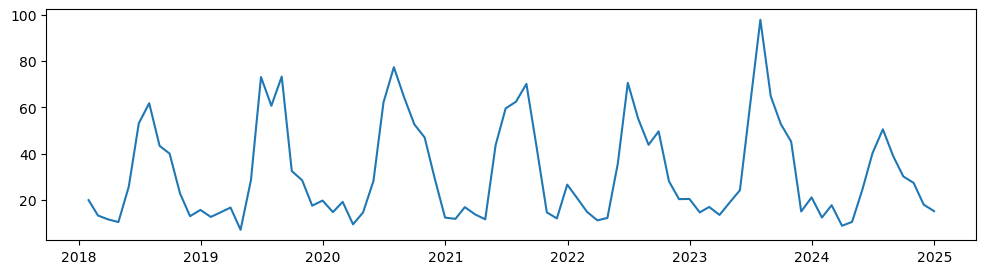

In [44]:
IRR_clippedM_array = np.array(IRR_clippedM)
fig = plt.figure(figsize=(12,3))
plt.plot(IRR_clippedM.index,np.nanmean(IRR_clippedM_array,axis=1))

In [45]:
IRR_array = np.asarray(IRR_clippedd)
#IRR_array = np.asarray(IRR_clippedM)


IRRest = np.empty((IRR_array.shape[0], sm.shape[1],sm.shape[2]))
for i in range(IRR_array.shape[0]):
    IRRest[i,:,:] = IRR_array[i,:].reshape(sm.shape[1],sm.shape[2])

In [46]:
print (IRRest.shape) 

(2557, 134, 168)


In [47]:
# Saving the reprojected files to a hdf5 file
dout1 = h5py.File(r'IWU_2018_2024.hdf5','w')
dout1.create_dataset('IRR', data=IRRest[:,:,:])
dout1.create_dataset('lon', data=lon)
dout1.create_dataset('lat', data=lat)
dout1.close()